<a href="https://colab.research.google.com/github/alk05/routing-comparison-nwm-nextgen-troute/blob/main/visualizing_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Comparing NWM and Routing-Only datastream (and t-route)**

## Imports

In [1]:
import xarray as xr
import pandas as pd
import json
import matplotlib.pyplot as plt
import ipywidgets as widgets
from numpy import select
import itertools
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from matplotlib.dates import HourLocator
import seaborn as sns

## NWM

In [ ]:
# NWM dataset
base_path = '/content/drive/MyDrive/Research/June19th04/'
# base_path = '/content/drive/MyDrive/Research/Apr30th00/'

first_nwm_filename = f'{base_path}nwm.t04z.short_range.channel_rt.f001.conus.nc'
# first_nwm_filename = f'{base_path}nwm.t00z.short_range.channel_rt.f001.conus.nc'
with xr.open_dataset(first_nwm_filename) as ds_first:
    base_forecast_time = pd.to_datetime(ds_first.attrs['model_initialization_time'], format='%Y-%m-%d_%H:%M:%S', utc=True)

nwm_streamflows = []
for i in range(1, 19):
    hr_num = str(i).zfill(3) # Ensures f001 format
    filename = f'nwm.t04z.short_range.channel_rt.f{hr_num}.conus.nc'
    # filename = f'nwm.t00z.short_range.channel_rt.f{hr_num}.conus.nc'
    ds = xr.open_dataset(base_path + filename)
    streamflow_da = ds['streamflow']

    valid_time = base_forecast_time + pd.Timedelta(hours=i)

    # Expand dimensions to add 'time' and assign the correct valid_time
    streamflow_da = streamflow_da.expand_dims(time=[valid_time])
    nwm_streamflows.append(streamflow_da)

nwm_flow = xr.concat(nwm_streamflows, dim='time')

## NextGen Routing-Only

In [ ]:
# NextGen Routing-only dataset
df_ro = pd.read_parquet ('/content/drive/MyDrive/Research/June19th04/troute_output_202606190500.parquet')
# df_ro = pd.read_parquet ('/content/drive/MyDrive/Research/Apr30th00/troute_output_202604300100.parquet')
# Ensure 'time' column is UTC-aware before setting as index
df_ro['time'] = pd.to_datetime(df_ro['time'], utc=True)
df_ro = df_ro.set_index(['feature_id', 'time'])
ds_ro = df_ro.to_xarray()
ro_flow = ds_ro['flow']

In [ ]:
# Crosswalk NWM and NextGen IDs
with open('/content/drive/MyDrive/Research/nwm_to_ngen_map.json', 'r') as f:
  mapping_dict = json.load(f)
convert_id = pd.Series(mapping_dict)

# print(convert_id['nex-492001'])

## T-Route

In [ ]:
# t_route
df_t_route = pd.read_parquet('/content/drive/MyDrive/Research/June19th04/flowveldepth_2026-07-01T13:05:35.034852.parquet')
# df_t_route = pd.read_parquet('/content/drive/MyDrive/Research/Apr30th00/flowveldepth_2026-07-01T11:03:51.645850.parquet')
df_t_route['value_time'] = pd.to_datetime(df_t_route['value_time'], utc=True)
df_t_route = df_t_route.set_index(['location_id','value_time'])

## Gage Data

In [ ]:
# Gage data
walnut_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/walnut creek gage data.xlsx', usecols=['time', 'value'])
mulberry_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/mulberry_creek_gage.xlsx', usecols=['time', 'value'])
cahaba_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/cahaba river gage data.xlsx', usecols=['time', 'value'])

## Data Retrieval



In [ ]:
# data retrieval
def get_comparison_data(id, zero_threshold=0.2, selected_gage_df=None):

    ro_series = ro_flow.sel(feature_id=id).to_pandas()

    nwm_ids_raw = convert_id.get(f'nex-{str(id)}', [])
    filtered_nwm_data_dict = {} # Stores {nwm_id: nwm_series}
    filtered_nwm_ids = []
    nwm_series_list = []

    troute_data_dict = {} # Stores {troute_id: troute_series}
    troute_series_list = [] # For calculating the mean

    nwm_mean_series = None
    if nwm_ids_raw:
        for n_id in nwm_ids_raw:
            nwm_individual_series = nwm_flow.sel(feature_id=n_id).to_pandas() # Get series directly
            if not nwm_individual_series.empty and nwm_individual_series.max() > zero_threshold:
                filtered_nwm_ids.append(n_id)
                filtered_nwm_data_dict[f'nwm_flow_{int(n_id)}'] = nwm_individual_series
                nwm_series_list.append(nwm_individual_series)

        if nwm_series_list:
            # Concatenate series into a DataFrame and calculate mean along columns
            nwm_mean_series = pd.concat(nwm_series_list, axis=1, join='outer').mean(axis=1)

    if filtered_nwm_ids:
        for n_id in filtered_nwm_ids:
            troute_location_id = f'nex-{int(n_id)}'
            try:
                troute_streamflow_series = df_t_route.loc[(troute_location_id, slice(None)), :]
                troute_streamflow_series = troute_streamflow_series[troute_streamflow_series['variable_name'] == 'streamflow']['value']
                if not troute_streamflow_series.empty:
                    troute_streamflow_series = troute_streamflow_series.reset_index(level='location_id', drop=True)
                    troute_streamflow_series.index = pd.to_datetime(troute_streamflow_series.index)
                    # troute_streamflow_series_hourly = troute_streamflow_series.resample('h').mean()
                    if not troute_streamflow_series.isnull().all():
                        troute_data_dict[f't_route_{int(n_id)}'] = troute_streamflow_series
                        troute_series_list.append(troute_streamflow_series)
            except KeyError:
                pass

    troute_mean_series = None
    if troute_series_list:
        # Concatenate series into a DataFrame and calculate mean along columns
        troute_mean_series = pd.concat(troute_series_list, axis=1, join='outer').mean(axis=1)

    # Process gage data
    gage_data_series = None
    if selected_gage_df is not None and not selected_gage_df.empty:
        gage_df = selected_gage_df.copy()
        gage_df['time'] = pd.to_datetime(gage_df['time'], utc=True)
        gage_df = gage_df.set_index('time').sort_index()

        # Filter gage data for the requested time range.
        start_time = pd.Timestamp('2026-06-19 04:00:00', tz='UTC')
        end_time = pd.Timestamp('2026-06-19 22:00:00', tz='UTC')
        # start_time = pd.Timestamp('2026-04-30 00:00:00', tz='UTC')
        # end_time = pd.Timestamp('2026-04-30 19:00:00', tz='UTC')
        gage_df = gage_df.loc[start_time:end_time]
        gage_data_series = gage_df['value'] * 0.0283168 # convert to metric

    return ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series,  gage_data_series

##Make Plot

In [ ]:


def plot_data(id, zero_threshold=0.2, selected_gage_df=None):
    plt.figure(figsize=(10,6)) # Changed to make the plot square

    ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series, gage_data_series = \
        get_comparison_data(id, zero_threshold, selected_gage_df=selected_gage_df)

    # Define specific color palettes as requested
    # Generate a muted seaborn palette to pick specific colors
    full_seaborn_palette = sns.color_palette("muted", n_colors=10)

    gage_color = full_seaborn_palette[4] # purple
    nextgen_color = full_seaborn_palette[7] # grey

    nwm_individual_colors_cycle = itertools.cycle(sns.color_palette("YlOrRd", n_colors=10)) # Warm tones for individual NWM
    nwm_average_color = full_seaborn_palette[1] # orange

    troute_individual_colors_cycle = itertools.cycle(sns.color_palette("GnBu", n_colors=10)) # Cool tones for individual t_route
    troute_average_color = full_seaborn_palette[0] # blue

    # Plot gage data
    if gage_data_series is not None and not gage_data_series.isnull().all():
        plt.plot(gage_data_series.index, gage_data_series.values, label='Gage Data', color=gage_color, linewidth=3)

    # Plot NextGen routing-only
    plt.plot(ro_series.index, ro_series.values, label=f'NextGen {id}', color=nextgen_color, linewidth=3, linestyle='-.')

    # Plot individual NWM
    sorted_nwm_labels = sorted(filtered_nwm_data_dict.keys())
    for nwm_label in sorted_nwm_labels:
        nwm_individual_series = filtered_nwm_data_dict[nwm_label]
        nwm_id = int(nwm_label.replace('nwm_flow_', ''))
        plt.plot(nwm_individual_series.index, nwm_individual_series.values, label=f'NWM {nwm_id}', color=next(nwm_individual_colors_cycle), linestyle='--', alpha=0.7, linewidth=0.75)

    # Plot individual t_route
    sorted_troute_labels = sorted(troute_data_dict.keys())
    for troute_label in sorted_troute_labels:
        troute_individual_series = troute_data_dict[troute_label]
        troute_nwm_id = int(troute_label.replace('t_route_', ''))
        plt.plot(troute_individual_series.index, troute_individual_series.values, label=f't_route {troute_nwm_id}', color=next(troute_individual_colors_cycle), linestyle='-', alpha=0.7, linewidth=0.75)

    # t-route average
    if troute_mean_series is not None:
        plt.plot(troute_mean_series.index, troute_mean_series.values, label='t_route Average', color=troute_average_color, linewidth=5, linestyle='-')

    # NWM average
    if nwm_mean_series is not None:
        plt.plot(nwm_mean_series.index, nwm_mean_series.values, label='NWM Average', color=nwm_average_color, linewidth=4, linestyle='--')



    # Formatting

    plt.xlabel('Time')
    plt.ylabel('Flow Rate (m$^3/$s)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # Set x-axis major ticks to every four hours and minor ticks to every hour
    plt.gca().xaxis.set_major_locator(HourLocator(interval=3))
    plt.gca().xaxis.set_minor_locator(HourLocator(interval=1))
    # Set more ticks on the y-axis
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
    plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Display ticks on all four sides with increased length
    plt.tick_params(axis='x', which='major', bottom=True, top=True, direction='in', length=8)
    plt.tick_params(axis='x', which='minor', bottom=True, top=True, direction='in', length=4)
    plt.tick_params(axis='y', which='major', left=True, right=True, direction='in', length=8)
    plt.tick_params(axis='y', which='minor', left=True, right=True, direction='in', length=4)
    plt.grid(axis='x', alpha=.3, linestyle=':')
    plt.grid(axis='y', alpha=.3, linestyle=':')

    plt.tight_layout()
    plt.show()

##Combine to one DataFrame

In [ ]:
def combine_data_frames(id, zero_threshold=0.2, selected_gage_df=None):
    ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series, gage_data_series = \
        get_comparison_data(id, zero_threshold, selected_gage_df=selected_gage_df)

    # Create a list of all series to merge
    all_series = []
    all_series.append(ro_series.rename('routing-only'))
    if troute_mean_series is not None:
        all_series.append(troute_mean_series.rename('t_route_flow_average'))
    if nwm_mean_series is not None:
        all_series.append(nwm_mean_series.rename('nwm_flow_average'))
    if gage_data_series is not None:
        all_series.append(gage_data_series.rename('gage_data'))

    for nwm_label, nwm_individual_series in filtered_nwm_data_dict.items():
        all_series.append(nwm_individual_series.rename(nwm_label))
    for troute_label, troute_individual_series in troute_data_dict.items():
        all_series.append(troute_individual_series.rename(troute_label))

    # Merge all series using their indices with an outer join to keep all time points
    flow_comparison = pd.concat(all_series, axis=1, join='outer')

    # Filter to only include 'on the hour' timestamps
    flow_comparison = flow_comparison[flow_comparison.index.minute == 0]

    return flow_comparison


## Show plot & dataframe

In [ ]:
def show_combined_info():
  id_str = input("Enter a NextGen ID: ")
  full_id_key = f'nex-{id_str}'
  if full_id_key in convert_id.index:
    id = int(id_str)
  else:
    print(f"Invalid ID number: {id_str}")
    return

  selected_gage_df = None
  if id == 497369:
      selected_gage_df = walnut_gage
  elif id == 497368:
      selected_gage_df = walnut_gage
  elif id == 492001:
      selected_gage_df = mulberry_gage
  elif id == 492000:
      selected_gage_df = mulberry_gage
  elif id == 491344:
      selected_gage_df = cahaba_gage
  elif id == 491343:
      selected_gage_df = cahaba_gage

  plot_data(id, selected_gage_df=selected_gage_df)
  print("\nCombined Flow Comparisons:")
  pd.set_option('display.max_columns', None) # display all columns.
  pd.set_option('display.max_rows', None)
  display(combine_data_frames(id, selected_gage_df=selected_gage_df))

  return

# Plots
Walnut Creek: 497369, 497368\
Mulberry Creek: 492001, 492000\
Cahaba River: 491344, 491343

Enter a NextGen ID: 492001


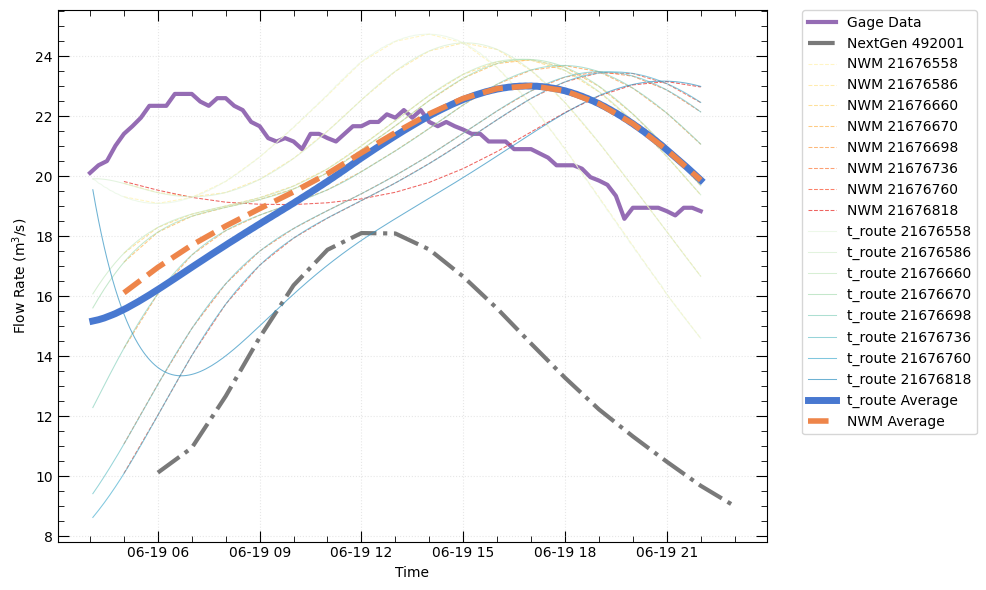


Combined Flow Comparisons:


,routing-only,t_route_flow_average,nwm_flow_average,gage_data,nwm_flow_21676586,nwm_flow_21676558,nwm_flow_21676760,nwm_flow_21676736,nwm_flow_21676698,nwm_flow_21676670,nwm_flow_21676660,nwm_flow_21676818,t_route_21676586,t_route_21676558,t_route_21676760,t_route_21676736,t_route_21676698,t_route_21676670,t_route_21676660,t_route_21676818
2026-06-19 04:00:00+00:00,NaN,NaN,NaN,20.104928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-19 05:00:00+00:00,NaN,15.553886,16.108750,21.407501,19.760000,19.310000,10.090000,11.070000,14.260000,17.130000,17.430000,19.820000,19.754307,19.312849,10.081625,11.064836,14.262052,17.125481,17.427237,15.402704
2026-06-19 06:00:00+00:00,10.114529,16.216179,16.957500,22.341955,19.450000,19.090000,12.030000,13.060000,16.080000,18.130000,18.290000,19.530000,19.447334,19.087076,12.025568,13.054065,16.078650,18.131947,18.285933,13.618863
2026-06-19 07:00:00+00:00,10.941051,16.960227,17.698750,22.738390,19.310000,19.290000,14.020000,14.920000,17.370000,18.660000,18.730000,19.290000,19.312363,19.290449,14.015101,14.914987,17.368214,18.659960,18.732283,13.388461
2026-06-19 08:00:00+00:00,12.663983,17.695950,18.335000,22.596806,19.450000,19.820000,15.730000,16.410000,18.180000,18.960000,19.000000,19.130000,19.453381,19.822884,15.729814,16.411522,18.182655,18.957247,19.002840,14.007258
2026-06-19 09:00:00+00:00,14.619889,18.404249,18.913750,21.662352,19.890000,20.630000,17.030000,17.500000,18.700000,19.220000,19.280000,19.060000,19.890581,20.630335,17.023291,17.494032,18.698559,19.216284,19.276682,15.004230
2026-06-19 10:00:00+00:00,16.358625,19.097974,19.472500,21.152650,20.590000,21.620000,17.930000,18.250000,19.100000,19.570000,19.670000,19.050000,20.587759,21.615986,17.931686,18.251223,19.096863,19.571905,19.665112,16.063259
2026-06-19 11:00:00+00:00,17.544292,19.821046,20.080000,21.265917,21.500000,22.689999,18.600000,18.850000,19.540000,20.110000,20.240000,19.110000,21.496454,22.693571,18.603539,18.848026,19.543421,20.113520,20.242722,17.027113
2026-06-19 12:00:00+00:00,18.100313,20.603247,20.776250,21.662352,22.539999,23.799999,19.180000,19.410000,20.150000,20.880000,21.010000,19.240000,22.539131,23.798946,19.184061,19.413374,20.145859,20.879757,21.007774,17.857077
2026-06-19 13:00:00+00:00,18.086153,21.339573,21.448750,21.945520,23.489999,24.489999,19.770000,20.020000,20.840000,21.670000,21.850000,19.460000,23.495718,24.488285,19.770611,20.022280,20.839649,21.673832,21.847414,18.578794


In [ ]:
show_combined_info()